1.Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, confusion_matrix,ConfusionMatrixDisplay, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


In [ ]:
#Load data

file_path = "/content/drive/MyDrive/WA_Fn-UseC_-Telco-Customer-Churn.csv"
telco_df = pd.read_csv(file_path)
telco_df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
telco_df.shape

(7043, 21)

In [ ]:
telco_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Data Cleaning**

In [ ]:
#drop customer ID column
telco_df.drop('customerID', axis=1, inplace=True)

In [ ]:
telco_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
telco_df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
#print unique values in all columns
for col in telco_df.columns:
  print(f'{col}: {telco_df[col].unique()}')


gender: ['Female' 'Male']
SeniorCitizen: [0 1]
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
tenure: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
MonthlyCharges: [29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
TotalChar

In [ ]:
#missing values
telco_df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [ ]:
#change data type of total charges column from object to float
telco_df['TotalCharges'] = pd.to_numeric(telco_df['TotalCharges'], errors='coerce')

#confirm data type of total charges column
telco_df['TotalCharges'].dtype

dtype('float64')

In [ ]:
len(telco_df[telco_df['TotalCharges'].isna()])  #number of missing values in total charges column

11

In [ ]:
telco_df['TotalCharges'] = telco_df['TotalCharges'].fillna(0)
len(telco_df[telco_df['TotalCharges'].isna()]) # Confirm no more missing values

0

In [ ]:
telco_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [ ]:
#check class distribution of target column
print(telco_df['Churn'].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


**Insights**
1. Customer ID column was removed as it is not required for modelling
2. No missing values in the dataset
3. Missing values or empty strings in total charges column were replaced with 0
4. Class imbalance identified in the target column

**EXPLORATORY DATA ANALYSIS (EDA)**

In [ ]:
#Statistical summary of the dataset
telco_df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


1. About 16.2% of the customers are senior citizens
2. The average tenure ( months a customer has stayed with the company) is approximately 32 months
3. The average monthly charges is approximately $64 and total charges $2279
4. Tenure and Total charges have a minimum of 0 , which corresponds to new customers or those with missing TotalCharges that were imputed with 0. This is an important observation from the data cleaning step.

**NUMERICAL FEATURES ANALYSIS**

Understanding the distribution of numerical features

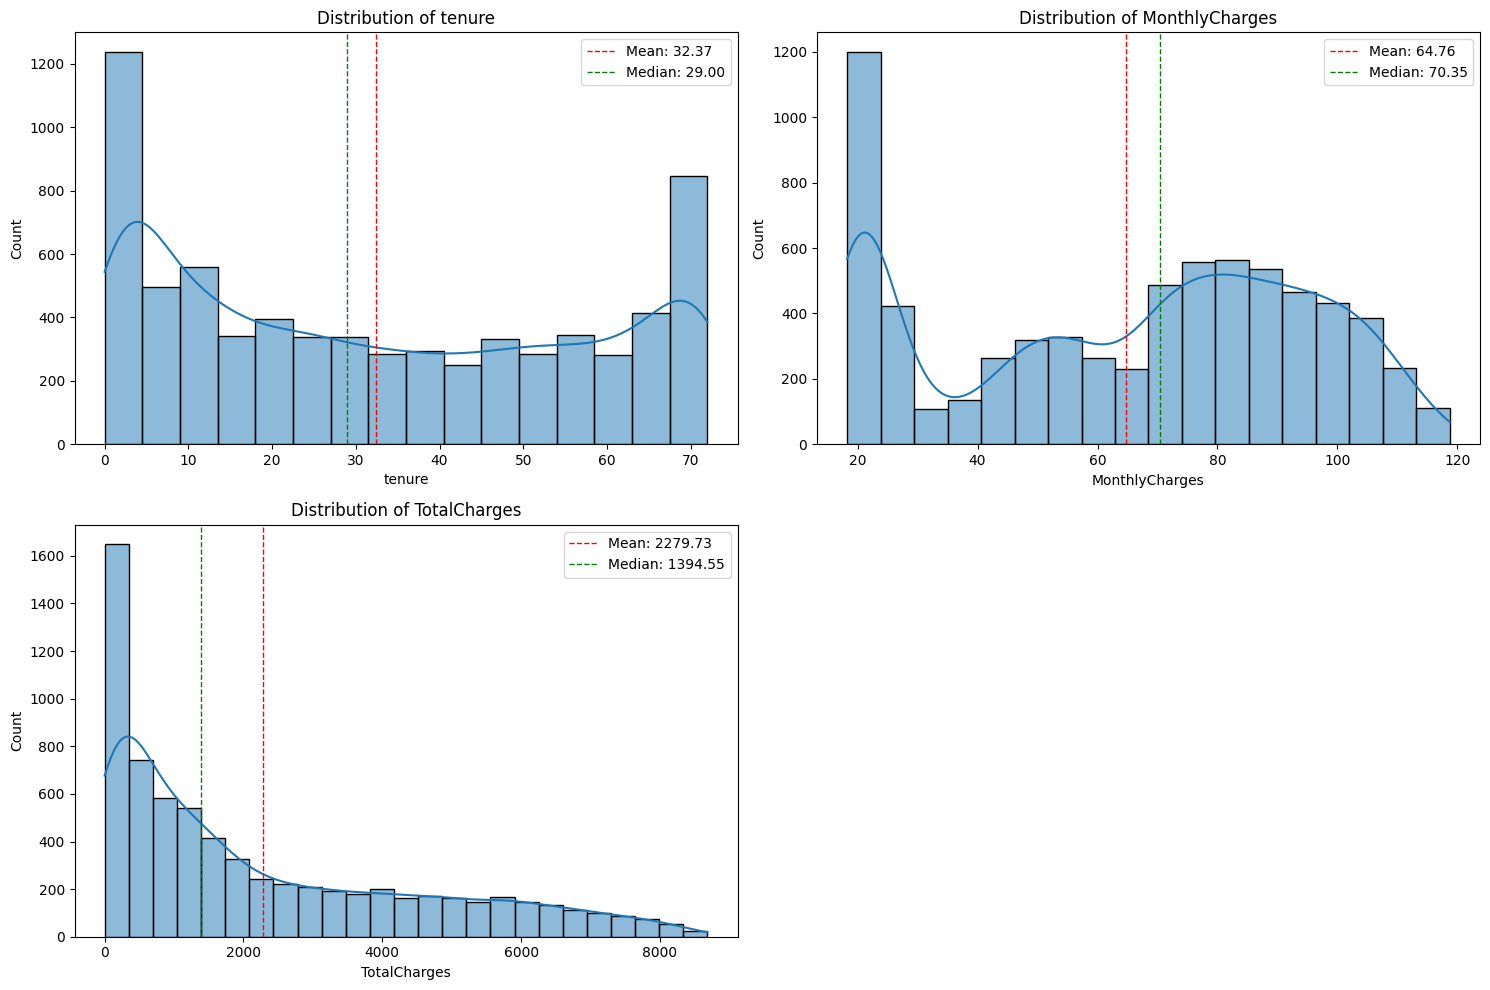

In [ ]:
def plot_histograms(telco_df, numerical_cols):
    num_cols = len(numerical_cols)
    # Determine the grid size for subplots
    # For 4 plots, a 2x2 grid is suitable
    rows = (num_cols + 1) // 2 # Ensures enough rows for all plots
    cols = 2 # Fixed to 2 columns for a horizontal arrangement

    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows)) # Adjust figure size
    axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

    for i, col in enumerate(numerical_cols):
        sns.histplot(telco_df[col], kde=True, ax=axes[i])
        axes[i].set_title(f'Distribution of {col}')

        #calculate the mean and median values for the columns
        mean_value = telco_df[col].mean()
        median_value = telco_df[col].median()

        #add vertical lines for mean and median
        axes[i].axvline(mean_value, color='red', linestyle='dashed', linewidth= 1, label=f'Mean: {mean_value:.2f}')
        axes[i].axvline(median_value, color = 'green', linestyle='dashed', linewidth=1, label=f'Median: {median_value:.2f}')

        axes[i].legend()

    # Hide any unused subplots if num_cols is not a perfect fit for the grid
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
    plt.show()

numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
plot_histograms(telco_df, numerical_cols)

1. **Tenure:** The distribution is right-skewed, indicating that a large number of customers have been with the company for a short period. This suggests that newer customers might be more prone to churn.
2. **MonthlyCharges:** This feature shows a bimodal distribution, implying that customers might fall into distinct groups based on their service tiers (e.g., basic vs. premium plans).
3. **TotalCharges:** This distribution is also heavily right-skewed, with most customers having lower total charges, which aligns with the observation of many customers having short tenures.


In [ ]:
#boxplot for numerical features


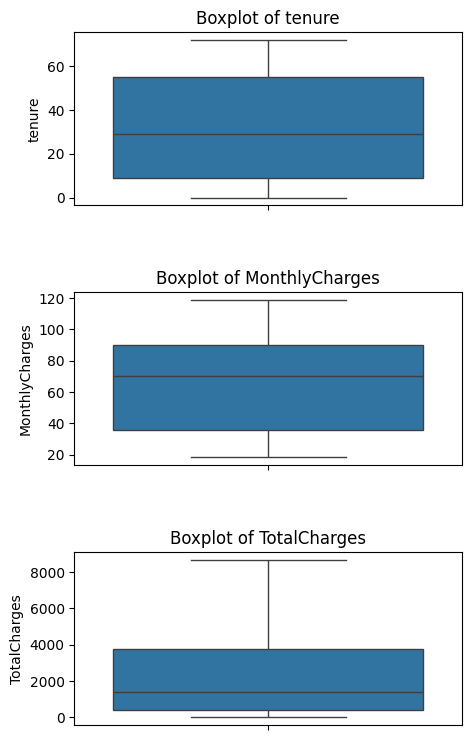

In [ ]:
def plot_boxplots(telco_df, numerical_cols):
    num_cols = len(numerical_cols)
    plt.figure(figsize=(5, 3 * num_cols))

    for i, col in enumerate(numerical_cols):
        plt.subplot(num_cols, 1, i + 1)
        sns.boxplot(y=telco_df[col])
        plt.title(f'Boxplot of {col}')
        plt.subplots_adjust(wspace=0.5, hspace=0.5)
    plt.show()

plot_boxplots(telco_df, numerical_cols)

1. **Tenure:** A wide range of customer tenures, with many customers having relatively short engagement, as shown by the median and distribution. No extreme outliers were identified.
2. **MonthlyCharges**: A diverse distribution of monthly charges, suggesting varied service plans among customers. The wide spread indicates significant variability in what customers pay.
3. **TotalCharges**: A heavily right-skewed distribution, meaning most customers have accumulated lower total charges, often corresponding to shorter tenures. The median is low, reinforcing that a large proportion of customers do not incur high total costs.

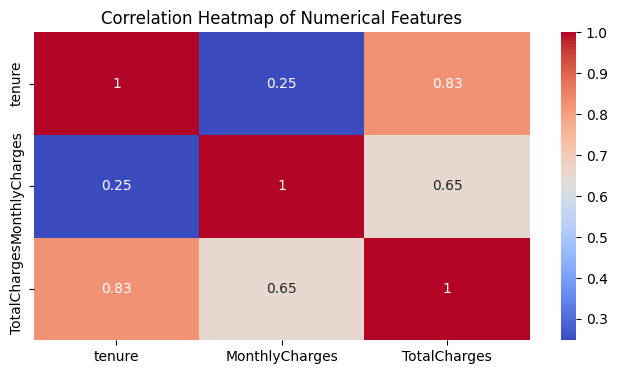

In [ ]:
#correlation heatmap for numerical features
plt.figure(figsize=(8, 4))
sns.heatmap(telco_df[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

TotalCharges is highly correlated with tenure and moderately correlated with MonthlyCharges, which makes sense as TotalCharges is derived from both. Tenure and MonthlyCharges have a weaker positive correlation with each other.

The longer a customer stays (tenure), the more they pay in total (TotalCharges). This makes perfect sense, as 'TotalCharges' is essentially 'MonthlyCharges' multiplied by 'tenure'. So, a long-term customer will naturally have a much higher total bill.

Customers with higher monthly bills (MonthlyCharges) also tend to have higher total bills (TotalCharges). This is also quite logical, as a higher monthly cost contributes directly to a higher overall cost over their time with the company.

The amount a customer pays each month (MonthlyCharges) doesn't strongly depend on how long they've been a customer (tenure). While there's a slight connection, it's not a major factor. This suggests that monthly charges are more about the services a customer chooses rather than how long they've been subscribed.

Tenure and TotalCharges (0.83): There is a very strong positive correlation (0.83) between 'tenure' and 'TotalCharges'. This is expected, as customers who stay longer with the company ('tenure') will naturally accumulate higher 'TotalCharges'. This high correlation suggests that as tenure increases, total charges tend to increase proportionally.

MonthlyCharges and TotalCharges (0.65): There is a moderately strong positive correlation (0.65) between 'MonthlyCharges' and 'TotalCharges'. This indicates that customers with higher monthly charges also tend to have higher total charges, which is logical, as total charges are an accumulation of monthly charges over time.

Tenure and MonthlyCharges (0.25): The correlation between 'tenure' and 'MonthlyCharges' is weak and positive (0.25). This suggests that while there might be a slight tendency for customers with longer tenures to have slightly higher monthly charges, it's not a strong relationship. This could imply that monthly charges are more influenced by the chosen service plan rather than simply the duration of the customer's stay.

**Categorical features Analysis**

In [ ]:
cat_cols = telco_df.select_dtypes(include=['object']).columns.tolist()
# Add 'SeniorCitizen' to categorical columns as it is a binary categorical feature
cat_cols.append('SeniorCitizen')

cat_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn',
 'SeniorCitizen']

In [ ]:
#barplot for cat cols


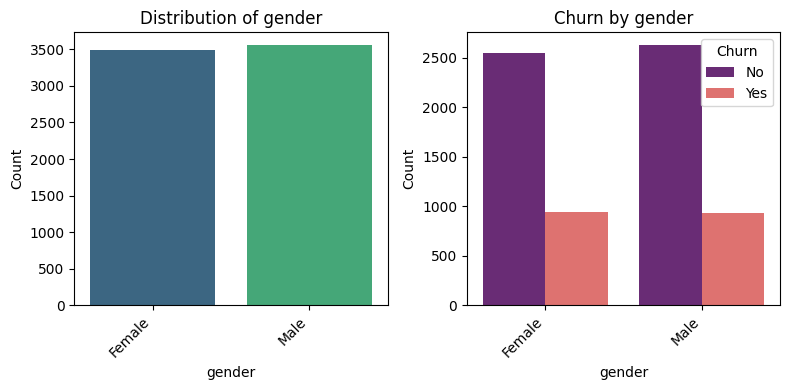

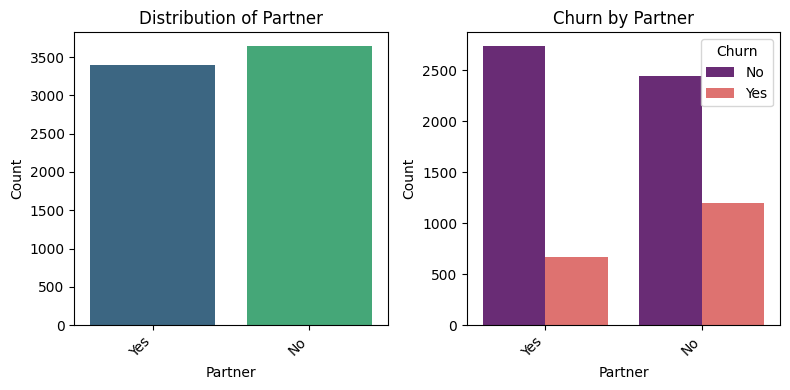

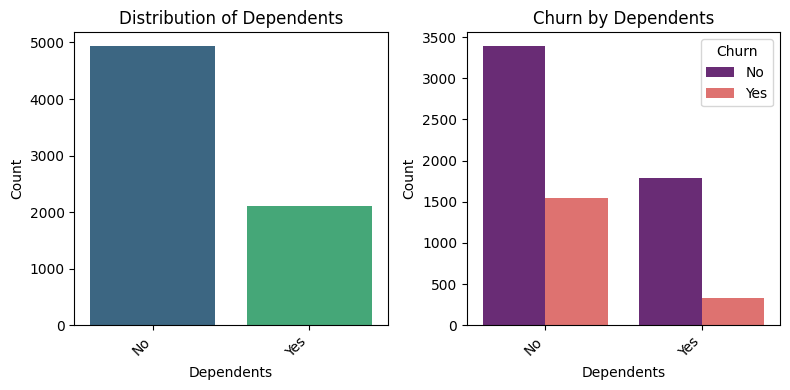

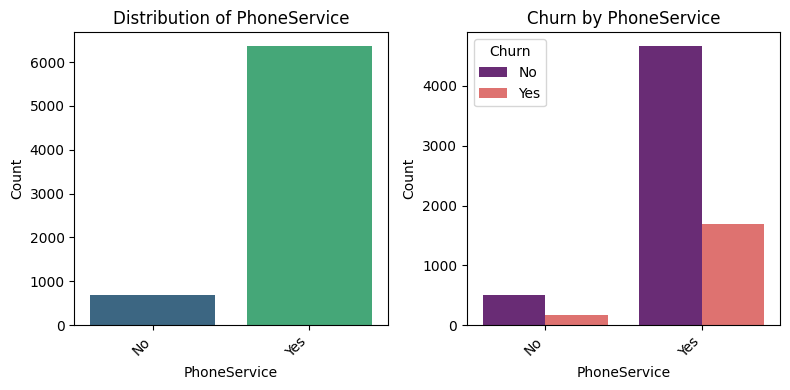

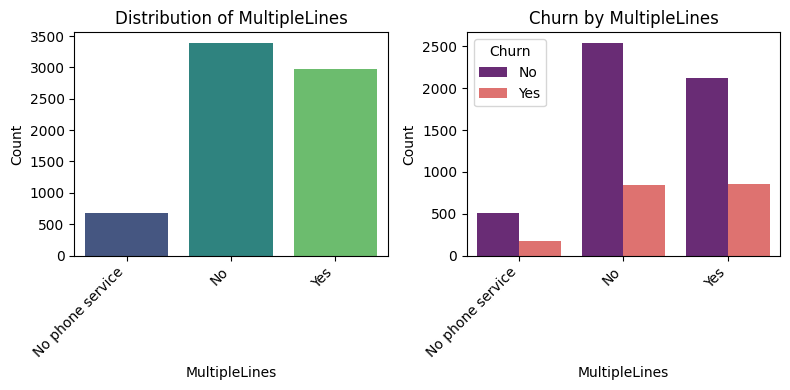

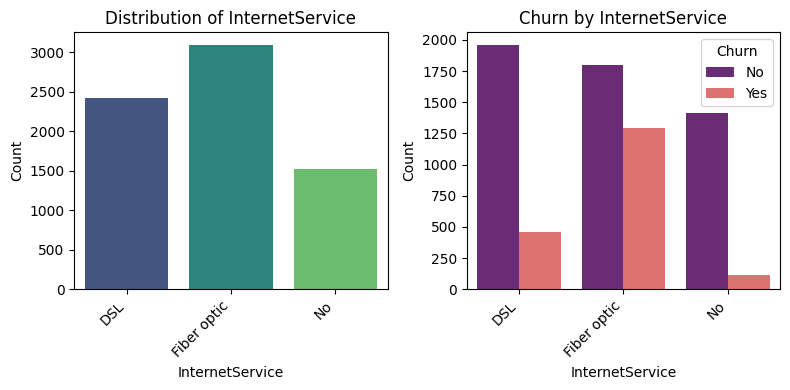

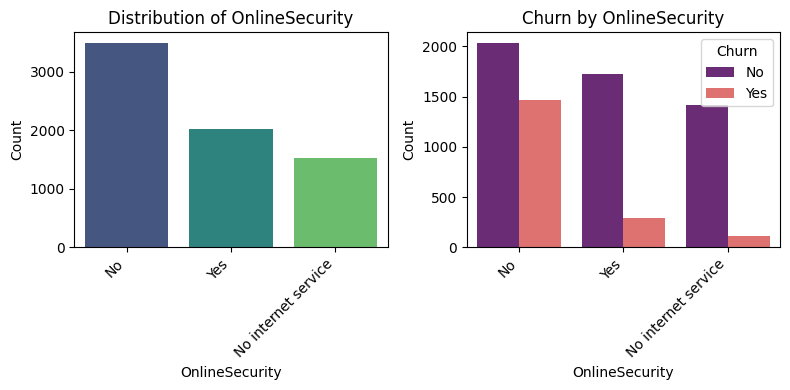

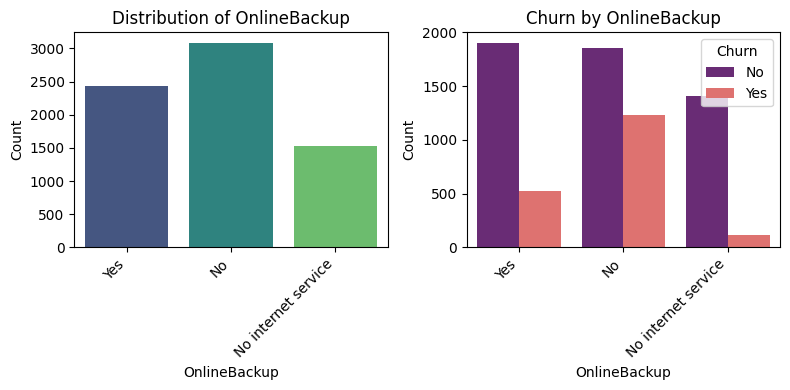

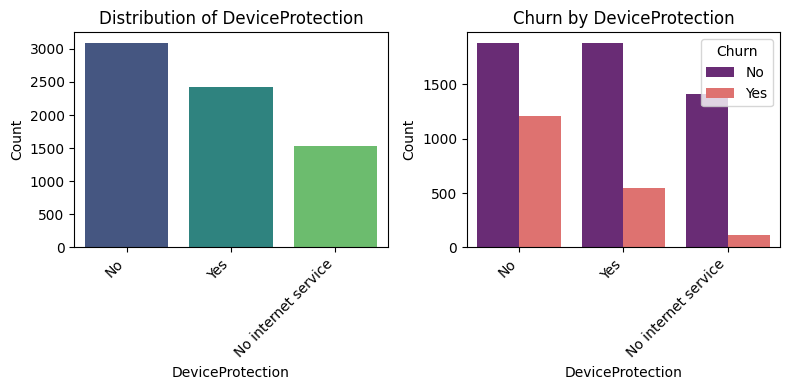

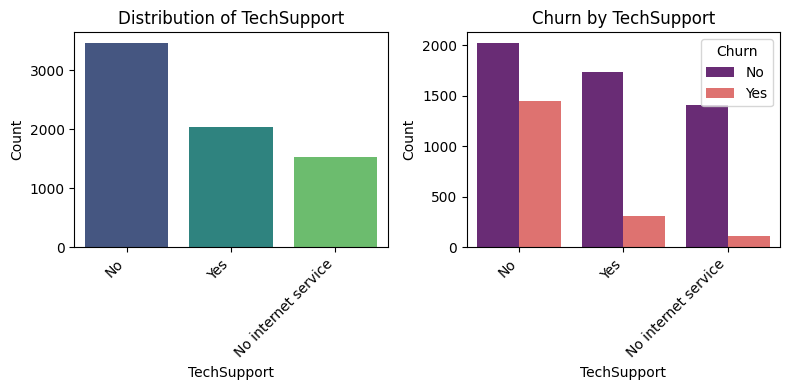

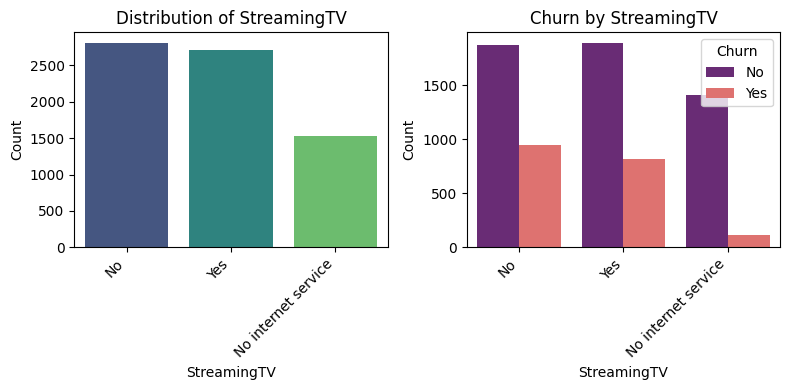

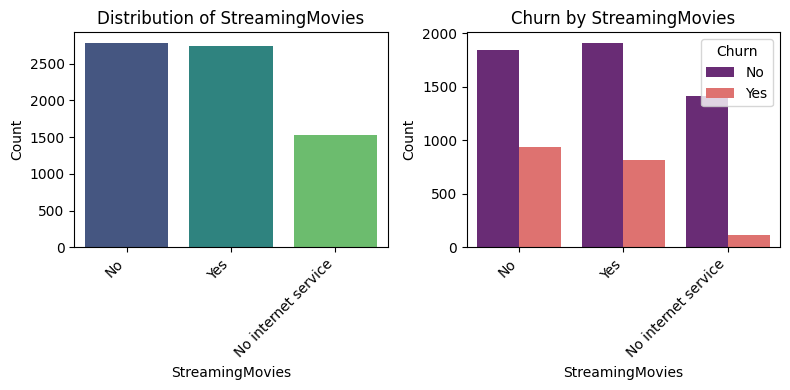

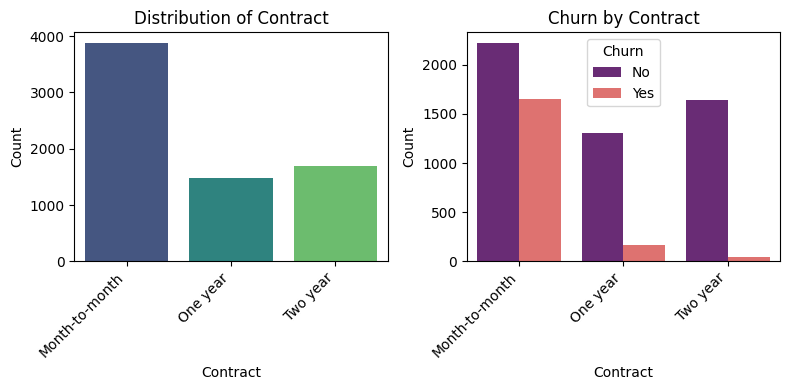

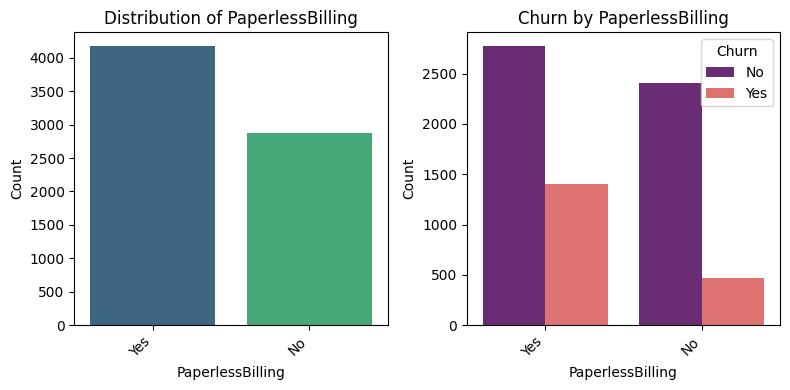

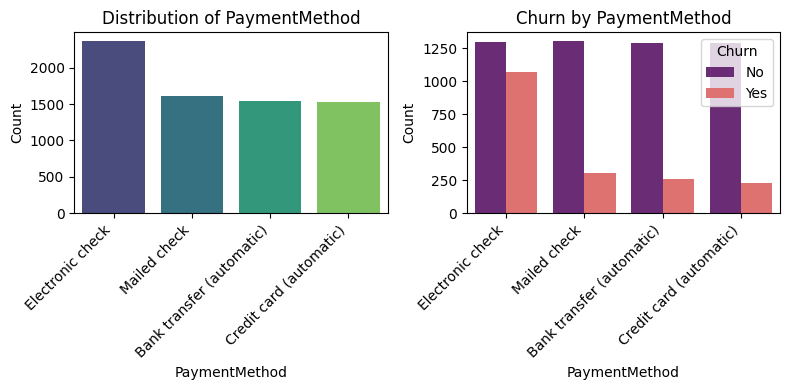

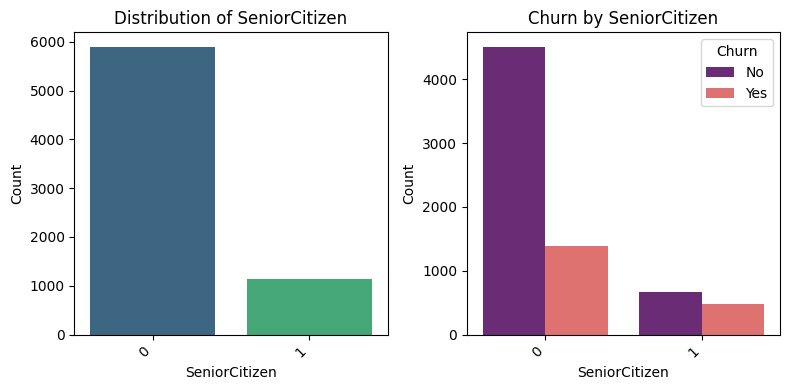

In [ ]:
def plot_categorical_distributions(df, categorical_cols, target_col='Churn'):
    for col in categorical_cols:
        if col == target_col:
            continue

        plt.figure(figsize=(8, 4))

        # Subplot 1: Distribution of the categorical feature
        plt.subplot(1, 2, 1)
        sns.countplot(data=df, x=col, hue=col, palette='viridis', legend=False)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')

        # Subplot 2: Churn rate by categorical feature
        plt.subplot(1, 2, 2)
        sns.countplot(data=df, x=col, hue=target_col, palette='magma')
        plt.title(f'Churn by {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')

        plt.tight_layout()
        plt.show()

# Visualize categorical features
plot_categorical_distributions(telco_df, cat_cols, target_col='Churn')

**Data preprocessing**

In [ ]:
# Label encode the target column 'Churn'
le = LabelEncoder()
telco_df['Churn'] = le.fit_transform(telco_df['Churn'])

In [ ]:
telco_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [ ]:
#value count for target column
print(telco_df['Churn'].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [ ]:
#define features and target
X = telco_df.drop('Churn', axis=1)
y = telco_df['Churn']

Train- Test split

In [ ]:
#train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Identifying Numerical and Categorical Features

In [ ]:
# Separate numerical and categorical features
# SeniorCitizen is binary (0/1) and can be treated as numerical for scaling, or as categorical for one-hot encoding.
# Given its nature, we will treat it as a numerical feature to be scaled along with others.
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Categorical features: these are object type and need encoding.
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical columns: {numerical_cols}")
print(f"Categorical columns: {categorical_cols}")

Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## Preprocessing Pipeline

In [ ]:
# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# Apply preprocessing to training and test data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Shape of X_train_processed:", X_train_processed.shape)
print("Shape of X_test_processed:", X_test_processed.shape)

Shape of X_train_processed: (5634, 45)
Shape of X_test_processed: (1409, 45)


In [ ]:
print (y_train.value_counts())


Churn
0    4138
1    1496
Name: count, dtype: int64


## Inspecting Encoded Categorical Features

In [ ]:
# Get feature names from the preprocessor after fitting
# The preprocessor contains 'num' for StandardScaler and 'cat' for OneHotEncoder

# Get numerical feature names
num_feature_names = numerical_cols

# Get categorical feature names after OneHotEncoding
cat_encoder = preprocessor.named_transformers_['cat']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_cols)

# Combine all feature names
all_feature_names = num_feature_names + list(cat_feature_names)

# Create a DataFrame from the processed training data with the correct column names
X_train_df = pd.DataFrame(X_train_processed, columns=all_feature_names)

# Display the head of the DataFrame to show the encoded categorical columns
display(X_train_df.head())

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,-0.437749,-0.465683,-0.000474,-0.419925,1.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,-0.437749,0.885537,1.074754,1.256017,1.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
2,-0.437749,-1.284605,-1.376499,-1.000283,0.0,1.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,-0.437749,-1.161766,0.177346,-0.905497,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,-0.437749,-1.325551,-0.098524,-1.010646,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0


In [ ]:
#view only encoded cat features
X_train_df[cat_feature_names]

,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,PhoneService_No,PhoneService_Yes,MultipleLines_No,MultipleLines_No phone service,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
2,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
5630,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
5631,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
5632,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [ ]:
#save encoded cat features to files
encoded_cat_features = X_train_df[cat_feature_names]
encoded_cat_features.to_pickle('encoded_cat_features.pkl')


## Handling Class Imbalance with SMOTE

In [ ]:
# Apply SMOTE to the training data to handle class imbalance
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)

print("Shape of X_train_resampled:", X_train_resampled.shape)
print("Shape of y_train_resampled:", y_train_resampled.shape)
print("Class distribution after SMOTE:\n", pd.Series(y_train_resampled).value_counts())

Shape of X_train_resampled: (8276, 45)
Shape of y_train_resampled: (8276,)
Class distribution after SMOTE:
 Churn
0    4138
1    4138
Name: count, dtype: int64


## Model Training and Evaluation



Training with default hyperparameters

In [ ]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42)
}

In [ ]:
# dictionary to store cross validation results
cv_scores = {}

#perform 5 fold cross validation for each model
for model_name, model in models.items():
    print(model_name)
    print(model)
    print("-" *50)

Decision Tree
DecisionTreeClassifier(random_state=42)
--------------------------------------------------
Random Forest
RandomForestClassifier(random_state=42)
--------------------------------------------------
XGBoost
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)
---------------------

In [ ]:
for model_name, model in models.items():
    scores = cross_val_score(model, X_train_resampled, y_train_resampled, cv=5, scoring='accuracy')
    cv_scores[model_name] = scores
    print(f"{model_name} Cross-Validation Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")

# Display all cross-validation scores
print("\nAll Cross-Validation Scores:")
for model_name, scores in cv_scores.items():
    print(f"{model_name}: {scores}")

Decision Tree Cross-Validation Accuracy: 0.7869 (+/- 0.0556)
Random Forest Cross-Validation Accuracy: 0.8519 (+/- 0.0661)
XGBoost Cross-Validation Accuracy: 0.8360 (+/- 0.0860)

All Cross-Validation Scores:
Decision Tree: [0.7071256  0.73172205 0.83141994 0.83141994 0.8326284 ]
Random Forest: [0.75543478 0.78851964 0.90694864 0.90030211 0.9081571 ]
XGBoost: [0.7089372  0.75649547 0.90755287 0.89305136 0.9141994 ]


The average accuracy for each model:
- Decision Tree: Approximately 78.69%
- Random Forest: Approximately 85.19%
- XGBoost: Approximately 83.60%

The Random Forest Classifier shows the highest average cross-validation accuracy , making it the best-performing model.

In [ ]:
print(y_test.value_counts())

Churn
0    1036
1     373
Name: count, dtype: int64


## Model Evaluation

Random Forest Evaluation:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86      1036
           1       0.61      0.57      0.59       373

    accuracy                           0.79      1409
   macro avg       0.73      0.72      0.72      1409
weighted avg       0.78      0.79      0.79      1409



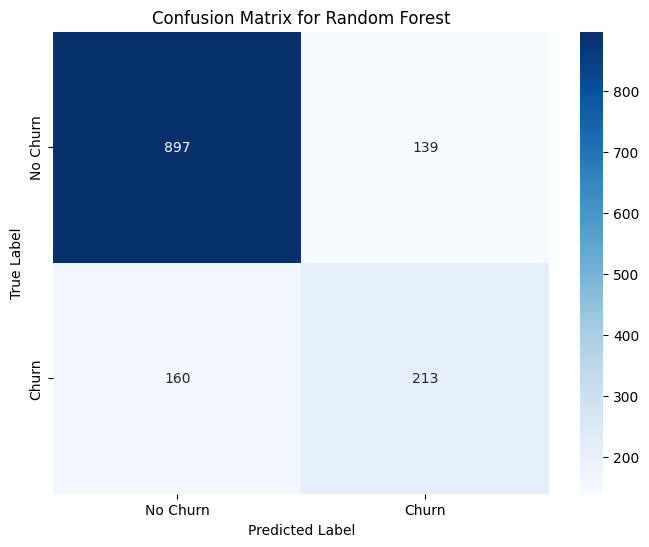

In [ ]:
# Train the Random Forest model on the resampled training data
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)

# Make predictions on the processed test set
y_pred_rf = rf_model.predict(X_test_processed)

#evaluate the model using classification report
print("Random Forest Evaluation:")
print(classification_report(y_test, y_pred_rf))


#confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix for Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

This confusion matrix shows:
- **True Negatives (897):** Correctly predicted non-churn customers.
- **False Positives (139):** Customers predicted to churn but actually didn't (Type I error).
- **False Negatives (160):** Customers predicted not to churn but actually did (Type II error).
- **True Positives (213):** Correctly predicted churn customers.


The model has a  low recall for churners. While it correctly identified many non-churn customers (897 True Negatives), it missed a substantial number of actual churners (160 False Negatives), classifying them as non-churners. This means that it was not effective enough at identifying the customers who were actually going to churn. To improve the model's ability to detect these crucial churn cases and reduce these 'false negatives,' we shall apply GridSearchCV for hyperparameter tuning, specifically optimizing for a higher recall score. This strategy aims to reduce the number of churners that the model fails to predict yet it's the project goal.

## Hyperparameter Tuning with GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Random Forest
param_grid = {
    'n_estimators': [100, 200], # Reduced number of trees in the forest
    'max_features': ['sqrt', 'log2'], # Number of features to consider at each split
    'max_depth': [10, 20, None], # Reduced maximum depth of the tree
    'min_samples_split': [2, 5], # Reduced minimum number of samples required to split a node
    'min_samples_leaf': [1, 2], # Reduced minimum number of samples required at each leaf node
    'criterion': ['gini', 'entropy'] # Function to measure the quality of a split
}

# Initialize the Random Forest Classifier
rf = RandomForestClassifier(random_state=42)

# Initialize GridSearchCV
# We use the resampled data for tuning to ensure the model learns from a balanced dataset
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=3, n_jobs=-1, verbose=2, scoring='recall') # Focusing on recall for churn

# Fit GridSearchCV to the data
grid_search.fit(X_train_resampled, y_train_resampled)

print("Best parameters found: ", grid_search.best_params_)
print("Best recall score found: ", grid_search.best_score_)

Fitting 3 folds for each of 96 candidates, totalling 288 fits
Best parameters found:  {'criterion': 'gini', 'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best recall score found:  0.8496656192087664


After hyperparameter tuning, we can use the `grid_search.best_estimator_` to make predictions and evaluate the model on the test set.

Tuned Random Forest Evaluation:
              precision    recall  f1-score   support

           0       0.89      0.81      0.85      1036
           1       0.57      0.72      0.64       373

    accuracy                           0.78      1409
   macro avg       0.73      0.76      0.74      1409
weighted avg       0.81      0.78      0.79      1409



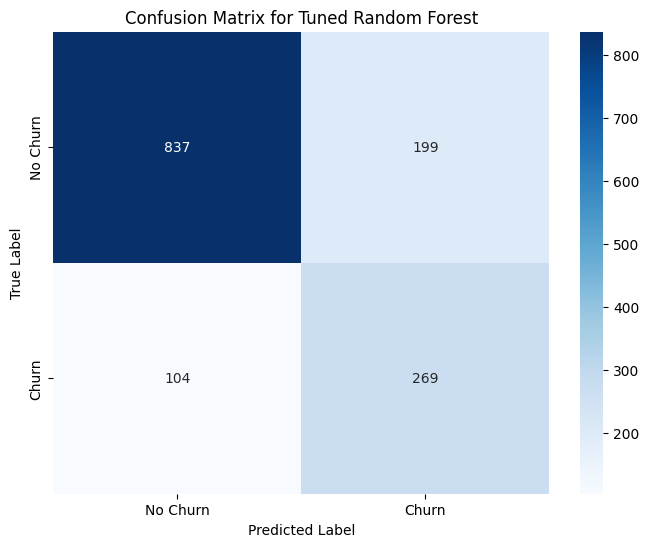

In [ ]:
# Get the best model from GridSearchCV
best_rf_model = grid_search.best_estimator_

# Make predictions on the processed test set with the best model
y_pred_tuned_rf = best_rf_model.predict(X_test_processed)

# Evaluate the tuned model using classification report
print("Tuned Random Forest Evaluation:")
print(classification_report(y_test, y_pred_tuned_rf))

# Plot Confusion Matrix for the tuned model
cm_tuned = confusion_matrix(y_test, y_pred_tuned_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix for Tuned Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

After hyperparameter tuning, the Random Forest model significantly improved its ability to detect customer churn. We observed a notable increase in True Positives (correctly identified churners) from 213 to 269, and a substantial decrease in False Negatives (actual churners missed by the model) from 160 to 104. This means the tuned model is much better at identifying customers who are likely to churn.

This improvement, however, came with a trade-off: an increase in False Positives (non-churners incorrectly predicted to churn) from 139 to 199. While this implies more incorrect churn predictions for stable customers, the reduction in missed churners (False Negatives) is generally more valuable for business, as retaining a customer is often more cost-effective than acquiring a new one. The overall accuracy might have slightly changed due to this focus on maximizing recall for the churn class.

## Feature Importance for Random Forest Classifier

Top 10 Most Important Features:


,Feature,Importance
3,TotalCharges,0.109659
1,tenure,0.108784
2,MonthlyCharges,0.099512
36,Contract_Month-to-month,0.070284
18,OnlineSecurity_No,0.057146
43,PaymentMethod_Electronic check,0.049833
38,Contract_Two year,0.038545
27,TechSupport_No,0.036115
16,InternetService_Fiber optic,0.025072
40,PaperlessBilling_Yes,0.022436


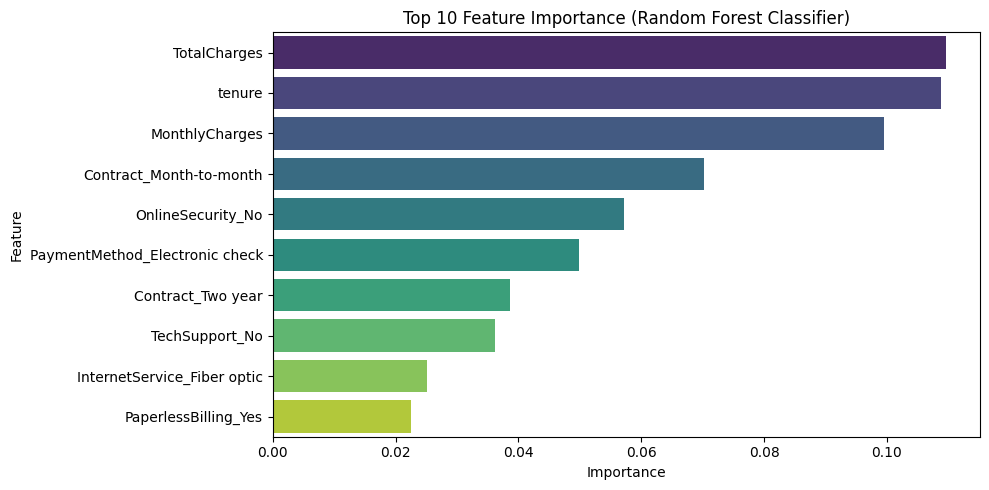

In [ ]:
# Get feature importances from the trained Random Forest model
feature_importances = rf_model.feature_importances_

# Create a DataFrame to store feature names and their importances
features_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': feature_importances
})

# Sort the features by importance in descending order
features_df = features_df.sort_values(by='Importance', ascending=False)

# Display the top N most important features
print("Top 10 Most Important Features:")
display(features_df.head(10))

# Plot the top 15 most important features
plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=features_df.head(10), hue='Feature', palette='viridis', legend=False)
plt.title('Top 10 Feature Importance (Random Forest Classifier)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

These features indicate that financial indicators (total and monthly charges), how long a customer stays with the company (tenure), the type of contract they have, and their utilization of security and tech support services are the most significant factors influencing churn decisions.

In [ ]:
import pickle
#save the trained model as a pickle file
model_data = {"model": best_rf_model, "features_names": X.columns.tolist()}

with open('customer_churn_model.pkl', 'wb') as file:
    pickle.dump(model_data,file)

## Load the saved model and build a predictive system

In [ ]:
with open ('customer_churn_model.pkl', 'rb') as file:
    model_data = pickle.load(file)

    loaded_model = model_data['model']
    features_names = model_data['features_names']

In [ ]:
print(loaded_model)

RandomForestClassifier(max_depth=10, max_features='log2', n_estimators=200,
                       random_state=42)


In [ ]:
print(features_names)

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [ ]:
input_data = {
    'gender': ['Female'],
    'SeniorCitizen': [0],
    'Partner': ['Yes'],
    'Dependents': ['No'],
    'tenure': [1],
    'PhoneService': ['No'],
    'MultipleLines': ['No phone service'],
    'InternetService': ['DSL'],
    'OnlineSecurity': ['No'],
    'OnlineBackup': ['Yes'],
    'DeviceProtection': ['No'],
    'TechSupport': ['No'],
    'StreamingTV': ['No'],
    'StreamingMovies': ['No'],
    'Contract': ['Month-to-month'],
    'PaperlessBilling': ['Yes'],
    'PaymentMethod': ['Electronic check'],
    'MonthlyCharges': [29.85],
    'TotalCharges': [29.85]
}

input_data_df = pd.DataFrame(input_data)

# Preprocess the new input data using the already fitted preprocessor
# This handles both numerical scaling and one-hot encoding for categorical features
input_data_processed = preprocessor.transform(input_data_df)

print(f"Shape of processed input data: {input_data_processed.shape}")


Shape of processed input data: (1, 45)


In [ ]:
# Make a prediction
prediction = loaded_model.predict(input_data_processed)

# Get prediction probability
prediction_proba = loaded_model.predict_proba(input_data_processed)[:, 1]

# prediction results
churn_status = 'Yes' if prediction[0] == 1 else 'No'

print(f"The predicted churn status for the new customer is: {churn_status}")
print(f"The probability of churning is: {prediction_proba[0]:.4f}")

The predicted churn status for the new customer is: Yes
The probability of churning is: 0.5961


 Based on the model, the customer is predicted to churn with a probability of 59.61%. This means there's a relatively high chance this customer will leave the service. We can use this information to trigger your retention strategies for this customer.